# 04 — Naive Bayes Classifier: Task Category Prediction

**Owner:** Sanjay
**Objective:** Train a Multinomial Naive Bayes classifier on TF-IDF features to predict `category` from task text.

**Scope of this notebook:**
- Build TF-IDF features (unigram vs. bigram) from `task_description` (+ `priority`/`status` as extra text signal)
- Tune the Laplace smoothing parameter `alpha` via cross-validated grid search
- Evaluate with accuracy, per-class & macro precision/recall/F1 — with special attention to the small `Research` class
- Confusion matrix heatmap + written observations on which categories get confused

> **Note on data:** This notebook currently runs on a 30-row sample dataset (`data/processed/tasks_nlp.csv`) provided during development. It is written so that swapping in the full dataset only requires changing the `DATA_PATH` variable in the cell below — no other code changes needed, as long as the column names (`task_description`, `category`, `priority`, `status`) match.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score, f1_score
)

sns.set_style("whitegrid")
pd.set_option("display.max_colwidth", 100)

DATA_PATH = "../data/processed/tasks_nlp.csv"

df = pd.read_csv(DATA_PATH)
print(f"Shape: {df.shape}")
df.head()

Shape: (8000, 14)


,task_id,task_description,description_processed,category,priority,status,created_date,due_date,days_to_deadline,estimated_hours,story_points,assignee_id,assignee_experience_years,assignee_open_tasks
0,TASK-12157,Add bulk export to CSV from the profile settings,add bulk export csv profile setting,Feature,Low,Blocked,2026-05-13,2026-05-31,18,9.9,2.0,USER-10,10.8,7
1,TASK-10453,Look into user reports about the mobile app,look user report mobile app,Research,High,Completed,2026-05-24,2026-06-18,25,12.9,2.0,USER-16,3.2,2
2,TASK-12716,Perform load testing on the checkout flow before release,perform load testing checkout flow release,Testing,Low,In Progress,2026-04-09,2026-04-23,14,6.3,8.0,USER-11,0.8,18
3,TASK-16240,Fix the crash in the analytics pipeline when the user submits an empty form,fix crash analytics pipeline user submits empty form,Bug Fix,Medium,Completed,2026-02-14,2026-02-19,5,1.5,1.0,USER-05,2.8,3
4,TASK-15364,Build a filtering and sorting option for the admin panel,build filtering sorting option admin panel,Feature,Low,Completed,2026-03-16,2026-04-05,20,4.3,3.0,USER-18,8.1,15


## 1. Explore the target class distribution

Naive Bayes (and macro-averaged metrics) are sensitive to class imbalance. We check the distribution up front — this is where we confirm `Research` is a minority class worth watching closely.

category
Bug Fix          1937
Feature          1642
Testing          1124
Maintenance      1070
Documentation     859
Deployment        827
Research          541
Name: count, dtype: int64


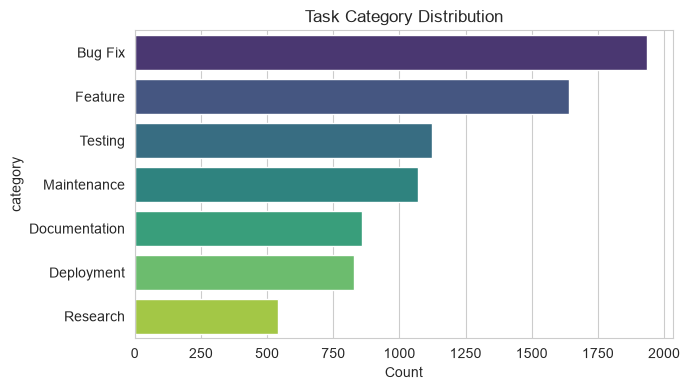


Smallest class: 'Research' with 541 samples (6.8% of data)


In [2]:
class_counts = df["category"].value_counts()
print(class_counts)

plt.figure(figsize=(7,4))
sns.barplot(x=class_counts.values, y=class_counts.index, hue=class_counts.index,
            palette="viridis", legend=False)
plt.xlabel("Count")
plt.title("Task Category Distribution")
plt.tight_layout()
plt.show()

min_class = class_counts.idxmin()
print(f"\nSmallest class: '{min_class}' with {class_counts.min()} samples "
      f"({class_counts.min()/len(df):.1%} of data)")

> **Sample-data caveat:** With only 30 rows and 7 classes, several classes (`Research`, `Documentation`, `Maintenance`, `Deployment`) have 1–2 examples. This is too few to reliably stratify into train/test splits or run 5-fold CV. The code below uses safeguards (reduced CV folds, warnings) that will no longer be necessary once the full dataset is loaded — but the *pipeline logic* is what matters and carries over unchanged.

## 2. Build the text field and train/test split

Per project decision, the text fed into TF-IDF combines `task_description` with `priority` and `status`, since these can carry category-relevant signal (e.g., "Critical" bugs vs. "Low" priority research tasks).

In [3]:
# Use the Week 1 preprocessed text and the SHARED stratified split saved by
# the feature-extraction notebook (models/), so Naive Bayes and SVM are
# evaluated on exactly the same train/test rows.
import joblib

train_idx = joblib.load("../models/train_idx.joblib")
test_idx = joblib.load("../models/test_idx.joblib")

X = df["description_processed"]
y = df["category"]

X_train, X_test = X.loc[train_idx], X.loc[test_idx]
y_train, y_test = y.loc[train_idx], y.loc[test_idx]

print(f"Train size: {len(X_train)}, Test size: {len(X_test)}")
print("\nTrain class counts:\n", y_train.value_counts())
print("\nTest class counts:\n", y_test.value_counts())

Train size: 6400, Test size: 1600

Train class counts:
 category
Bug Fix          1550
Feature          1314
Testing           899
Maintenance       856
Documentation     687
Deployment        661
Research          433
Name: count, dtype: int64

Test class counts:
 category
Bug Fix          387
Feature          328
Testing          225
Maintenance      214
Documentation    172
Deployment       166
Research         108
Name: count, dtype: int64


## 3. TF-IDF vectorization: unigram vs. bigram

We build two feature sets so we can directly compare whether adding bigrams (two-word phrases like "load testing" or "role based") improves separability between categories.

In [4]:
tfidf_uni = TfidfVectorizer(ngram_range=(1, 1), min_df=1)
tfidf_bi  = TfidfVectorizer(ngram_range=(1, 2), min_df=1)

Xtr_uni = tfidf_uni.fit_transform(X_train)
Xte_uni = tfidf_uni.transform(X_test)

Xtr_bi = tfidf_bi.fit_transform(X_train)
Xte_bi = tfidf_bi.transform(X_test)

print(f"Unigram vocab size: {len(tfidf_uni.vocabulary_)}")
print(f"Bigram (uni+bi) vocab size: {len(tfidf_bi.vocabulary_)}")

Unigram vocab size: 220
Bigram (uni+bi) vocab size: 1860


> **min_df note:** on the full dataset, raise `min_df` to 2–3 to drop rare noisy terms and keep the vocabulary generalizable. It's set to 1 here only because the sample is too small otherwise.

## 4. Tune alpha with GridSearchCV (scored on macro-F1)

We deliberately score the grid search on **macro-F1**, not accuracy. Accuracy would let the model ignore the small `Research` class entirely and still look good, since it's outnumbered by classes like `Feature`. Macro-F1 weights every class equally regardless of size.

In [5]:
alpha_grid = {"alpha": [0.01, 0.05, 0.1, 0.5, 1.0, 2.0, 5.0]}

# CV folds can't exceed the smallest class count in y_train
n_splits = max(2, min(5, y_train.value_counts().min()))
cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42) if y_train.value_counts().min() >= 2 else n_splits

def tune_alpha(Xtr, name):
    grid = GridSearchCV(
        MultinomialNB(), alpha_grid, scoring="f1_macro", cv=cv, error_score="raise"
    )
    grid.fit(Xtr, y_train)
    print(f"[{name}] best alpha = {grid.best_params_['alpha']}  "
          f"(CV macro-F1 = {grid.best_score_:.3f})")
    return grid

try:
    grid_uni = tune_alpha(Xtr_uni, "Unigram")
    grid_bi  = tune_alpha(Xtr_bi, "Bigram")
except ValueError as e:
    print("Grid search failed - most likely because the sample dataset is too small "
          "for cross-validation with this many classes.")
    print(f"Details: {e}")
    raise

[Unigram] best alpha = 0.1  (CV macro-F1 = 0.790)


[Bigram] best alpha = 0.01  (CV macro-F1 = 0.785)


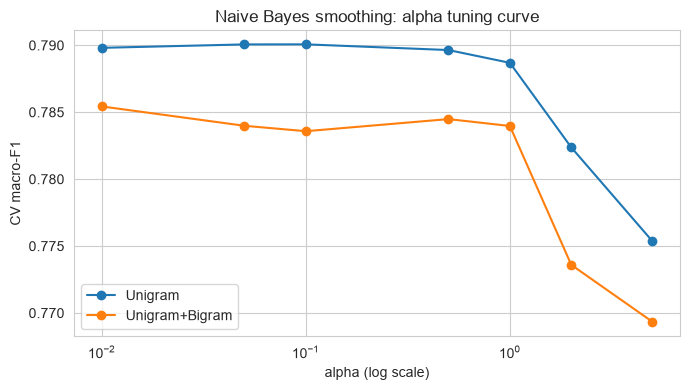

In [6]:
# Tuning curve: CV macro-F1 vs alpha for both feature sets
alphas = alpha_grid["alpha"]
plt.figure(figsize=(7, 4))
plt.plot(alphas, grid_uni.cv_results_["mean_test_score"], marker="o", label="Unigram")
plt.plot(alphas, grid_bi.cv_results_["mean_test_score"], marker="o", label="Unigram+Bigram")
plt.xscale("log")
plt.xlabel("alpha (log scale)")
plt.ylabel("CV macro-F1")
plt.title("Naive Bayes smoothing: alpha tuning curve")
plt.legend()
plt.tight_layout()
plt.show()

## 5. Evaluate both feature sets on the held-out test set

Per-class precision/recall/F1 plus macro averages — macro is the number to watch for `Research`.

In [7]:
def evaluate(name, model, Xte):
    preds = model.predict(Xte)
    acc = accuracy_score(y_test, preds)
    report = classification_report(y_test, preds, output_dict=True, zero_division=0)
    print(f"\n=== {name} (alpha={model.alpha}) ===")
    print(f"Accuracy: {acc:.3f}")
    print(classification_report(y_test, preds, digits=3, zero_division=0))
    return preds, report, acc

preds_uni, report_uni, acc_uni = evaluate("Unigram", grid_uni.best_estimator_, Xte_uni)
preds_bi,  report_bi,  acc_bi  = evaluate("Bigram",  grid_bi.best_estimator_,  Xte_bi)


=== Unigram (alpha=0.1) ===
Accuracy: 0.800
               precision    recall  f1-score   support

      Bug Fix      0.888     0.860     0.874       387
   Deployment      0.660     0.819     0.731       166
Documentation      0.740     0.826     0.780       172
      Feature      0.952     0.851     0.899       328
  Maintenance      0.647     0.720     0.681       214
     Research      0.696     0.657     0.676       108
      Testing      0.851     0.733     0.788       225

     accuracy                          0.800      1600
    macro avg      0.776     0.781     0.776      1600
 weighted avg      0.811     0.800     0.803      1600


=== Bigram (alpha=0.01) ===
Accuracy: 0.817
               precision    recall  f1-score   support

      Bug Fix      0.929     0.840     0.882       387
   Deployment      0.706     0.867     0.778       166
Documentation      0.786     0.855     0.819       172
      Feature      0.946     0.851     0.896       328
  Maintenance      0.709  

## 6. Metrics comparison table

In [8]:
results = pd.DataFrame([
    {
        "Feature Set": "Unigram",
        "Best Alpha": grid_uni.best_estimator_.alpha,
        "Accuracy": acc_uni,
        "Macro Precision": report_uni["macro avg"]["precision"],
        "Macro Recall": report_uni["macro avg"]["recall"],
        "Macro F1": report_uni["macro avg"]["f1-score"],
        "Research Recall": report_uni.get("Research", {}).get("recall", np.nan),
    },
    {
        "Feature Set": "Bigram",
        "Best Alpha": grid_bi.best_estimator_.alpha,
        "Accuracy": acc_bi,
        "Macro Precision": report_bi["macro avg"]["precision"],
        "Macro Recall": report_bi["macro avg"]["recall"],
        "Macro F1": report_bi["macro avg"]["f1-score"],
        "Research Recall": report_bi.get("Research", {}).get("recall", np.nan),
    },
])
results

,Feature Set,Best Alpha,Accuracy,Macro Precision,Macro Recall,Macro F1,Research Recall
0,Unigram,0.10,0.800000,0.776236,0.78090,0.775595,0.657407
1,Bigram,0.01,0.816875,0.789013,0.81196,0.797288,0.777778


## 7. Confusion matrix — best performing feature set

Best feature set by macro-F1: Bigram


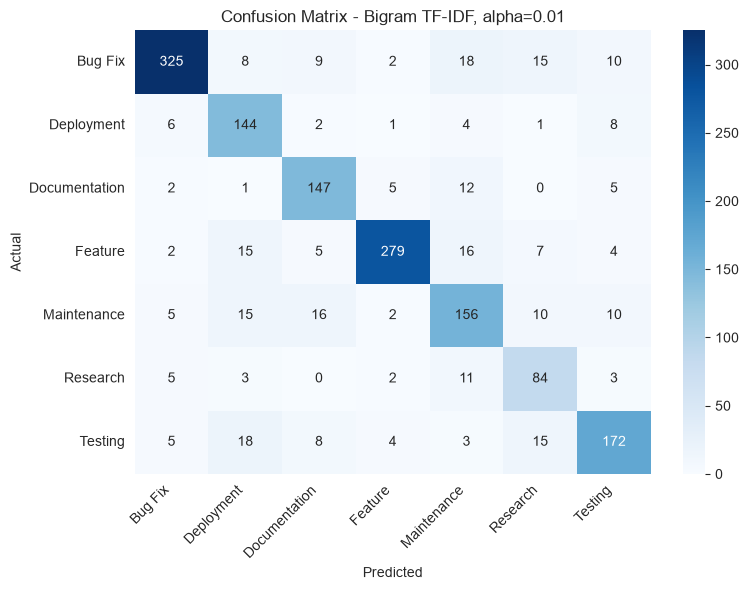

In [9]:
best_name, best_model, best_Xte, best_preds = (
    ("Bigram", grid_bi.best_estimator_, Xte_bi, preds_bi)
    if report_bi["macro avg"]["f1-score"] >= report_uni["macro avg"]["f1-score"]
    else ("Unigram", grid_uni.best_estimator_, Xte_uni, preds_uni)
)
print(f"Best feature set by macro-F1: {best_name}")

labels = sorted(y.unique())
cm = confusion_matrix(y_test, best_preds, labels=labels)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=labels, yticklabels=labels, cbar=True)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix - {best_name} TF-IDF, alpha={best_model.alpha}")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 8. Observations

*(Auto-drafted from the current run's numbers below — rewrite this section once the full dataset results are in; the sample is too small for the confusion patterns to be meaningful.)*

In [10]:
# Helper: find which categories get confused with which
cm_df = pd.DataFrame(cm, index=labels, columns=labels)
print("Confusion matrix:\n", cm_df)

print("\nOff-diagonal confusions (Actual -> Predicted, count):")
for actual in labels:
    for predicted in labels:
        if actual != predicted and cm_df.loc[actual, predicted] > 0:
            print(f"  {actual} -> {predicted}: {cm_df.loc[actual, predicted]}")

research_recall = report_bi.get("Research", report_uni.get("Research", {})).get("recall", None)
if research_recall is not None:
    print(f"\nResearch class recall (best model): {research_recall:.2f}")

Confusion matrix:
                Bug Fix  Deployment  Documentation  Feature  Maintenance  \
Bug Fix            325           8              9        2           18   
Deployment           6         144              2        1            4   
Documentation        2           1            147        5           12   
Feature              2          15              5      279           16   
Maintenance          5          15             16        2          156   
Research             5           3              0        2           11   
Testing              5          18              8        4            3   

               Research  Testing  
Bug Fix              15       10  
Deployment            1        8  
Documentation         0        5  
Feature               7        4  
Maintenance          10       10  
Research             84        3  
Testing              15      172  

Off-diagonal confusions (Actual -> Predicted, count):
  Bug Fix -> Deployment: 8
  Bug Fix -> Docum

**Notes to fill in once run on the full dataset:**

- Which categories are most often confused with each other, and do they share vocabulary (e.g., "Testing" vs "Bug Fix" both mention "test", "fix", "error")?
- Does `Research` get absorbed into a larger class? If so, which one, and why (shared words like "analyze", "review", "report")?
- Did bigrams help or hurt macro-F1 relative to unigrams? Bigrams can capture domain phrases ("load testing", "role based access") but can also fragment the already-small `Research`/`Documentation`/`Deployment` classes further by making the feature space sparser.
- What alpha won for each feature set, and does a higher alpha (more smoothing) help small classes at the cost of large-class precision?
